<a href="https://colab.research.google.com/github/valentinaslisser/valentina_slisser/blob/main/ftse_assignment_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fundamentals of Time Series Econometrics

## Assignment: Modelling US National Electricity Generation

This notebook is a part of the course *"Fundamentals of Time Series Econometrics"* by VU Amsterdam in the minor *"Applied Econometrics: A Big Data Experience for all"*. This notebook contains the assignment for this course and will cover modelling national electricity generation in the US.

### Instructions

The assignment is done in groups of **four** students. The deadline for this assignment is **Friday, 9th of October, 2026 at 23:59pm**. Handing in of the assignment is done through Canvas, note that only one member has to submit the work for the whole group. Make sure that names and student numbers of all group members are clearly stated in the document.

The assignment requires you to program using any sort of programming language or the use of some software package. Those who are familiar with a programming language (e.g. Python, R, MATLAB, OCTAVE, OxMetrics, Gauss, C++, Julia, Fortran, etc.) are encouraged to use it for the assignment. Those who are not familiar with a programming language are advised to use either Python or R. You may not use Stata, Eviews or Gretl.

The deliverable is a pdf file containing the answers to the questions and the code used to answer the questions. The code, output, and answer to each question should be clearly structured in the document. If you wish to obtain a good grade in the assignment, then your answers should be: correct, clear and complete. You should deliver an econometric report that provides appropriate justifications for each answer, as well as, insightful comments and remarks that highlight the key elements of your reasoning. Think about your report: Too much information is unreadable. Too little information is ill advised.

If you are using Python for the assignment you can directly work in this notebook and submit a pdf version of it on Canvas. If you are using R for the assignment I would recommend to use Rmarkdown in combination with Rstudio to create a similar setup as this notebook. One can convert the Rmarkdown file to a pdf file and submit it on Canvas. If none of the above mentioned situations applies or suits your workflow you can use your favorite text writing software and submit the pdf file on Canvas. Please make sure that the code is formatted in a clear and structured way and that it is combined with the output and the answer to the question.

Regarding the use of AI tools to support you in the assignment, please read the *AI in this course* page on Canvas under the *Course Manual* module.

### Data
The data describe the US monthly electricity generation from January 1973 to May 2026. More specifically, they pertain to total net generation across all sectors (MSN: ELETPUS). The data come from the U.S. Energy Information Administration ([source](https://www.eia.gov/totalenergy/data/browser/csv.php?tbl=T07.01)).  The series is provided in the `MER_T07_01.csv` file, which can be found in the *Data* module on Canvas.


### Structure
In total, you can get 100 points for the assignment. The assignment consists of five main parts. The parts and the point distribution are specified below.

* Part 1: Preparation (25 pts)
* Part 2: Baseline Model (15 pts)
* Part 3: Model Selection In-Sample (15 pts)
* Part 4: Model Selection Out-of-Sample (20 pts)
* Part 5: Benchmarking (25 pts)

## Group Information

Please provide the following information in this cell:
- Assignment group number
- Names of all group members
- Student numbers of all group members

## Libraries

Before you start, let's import some libraries. The following libraries might come in handy:

- `numpy` for numerical operations
- `pandas` for data manipulation
- `seaborn` for data visualization
- `statsmodels` for time series analysis

In [9]:
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.tsa.api as tsa
import statsmodels.api as sm

## Global Parameters

Let's set some global parameters for the notebook. We will set the style of the plots and the location of the data directory.

In [10]:
# set the style of the plots
sns.set_theme()

# directories
data_dir = '/content/'

# PART 1: Preparation (25 pts)

## 1. Load and visualize the US national electricity generation time series

In the cell below you are expected to load the US national electricity generation time series. The data are stored in the file `MER_T07_01.csv`. The file contains multiple columns of which `YYYYMM` and `Value` are important. The `YYYYMM` column contains the date value in a YYYYMM format value (e.g. 200001 for January 2000), and the `Value` column contains the US national electricity generation (in thousand Megawatthours). **Note:** In the csv file there are entries coded as month 13. These are annual totals which you need to exclude.

After loading the data, you should visualize the time series. The time series should be plotted with the dates in the form of years on the x-axis and the  electricity generation series on the y-axis.

Comment on the dynamics of the time series. What do you observe? Do you believe the time series is stationary and why?

Bestand niet gevonden. Bezig met downloaden van EIA website...
Download voltooid!


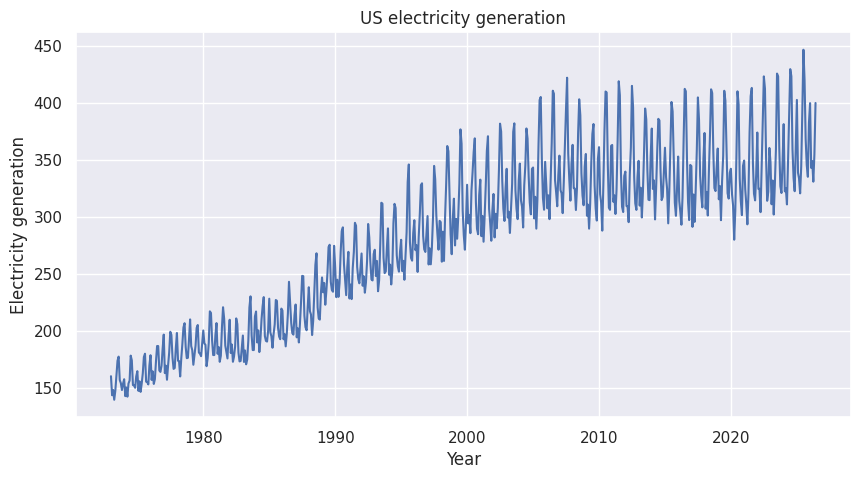

In [11]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import urllib.request

# Bestandsnaam en pad
csv_path = '/content/MER_T07_01.csv'

# Als het bestand nog niet bestaat, download het dan automatisch
if not os.path.exists(csv_path):
    print("Bestand niet gevonden. Bezig met downloaden van EIA website...")
    url = "https://www.eia.gov/totalenergy/data/browser/csv.php?tbl=T07.01"
    try:
        urllib.request.urlretrieve(url, csv_path)
        print("Download voltooid!")
    except Exception as e:
        print(f"Fout bij het downloaden: {e}")
        print("Upload het bestand handmatig via het bestanden-menu aan de linkerkant.")

# Data inlezen
if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)

    # We gebruiken alleen de totale US elektriciteitsproductie
    data = df[df['MSN'] == 'ELETPUS'].copy()

    # Verwijder maand 13 omdat dit jaarlijkse totalen zijn
    data['month'] = data['YYYYMM'] % 100
    data = data[data['month'] != 13]

    # Maak datum- en waardevariabelen aan
    data['Date'] = pd.to_datetime(data['YYYYMM'].astype(str), format='%Y%m')
    data['Value'] = pd.to_numeric(data['Value'], errors='coerce')

    # Behoud alleen de benodigde variabelen
    data = data[['Date', 'Value']]
    data = data.dropna()
    data = data.set_index('Date')

    # Plotten
    plt.figure(figsize=(10,5))
    plt.plot(data.index, data['Value'])
    plt.xlabel('Year')
    plt.ylabel('Electricity generation')
    plt.title('US electricity generation')
    plt.show()
else:
    print("Kan de code niet uitvoeren omdat het bestand ontbreekt.")

As time progresses, there is an increase in the values and the series displays a seasonality pattern. Seasonal variations appear to be growing with the passage of time. Thus, the original time series is non-stationary since it has a non-constant mean and variance.

As time progresses, there is an increase in the values and the series displays a seasonality pattern. Seasonal variations show to be growing with the passage of time. Thus, the original time series is non-stationary in nature since it has a non-constant mean and variance.

## 2. Autocorrelation and Partial Autocorrelation

To gain a better understanding of the dynamics in US national electricity generation time series you are asked to plot the autocorrelation function (ACF) and partial autocorrelation function (PACF) of the time series in the cell below. You can set the amount of lags equal to 36 (equivalent to 3 years).

What do you observe in the ACF and PACF plots? What data transformations would you apply to the time series? What kind of dynamics are present in the time series?

Do you see any seasonal patterns in the ACF and PACF plots? Is this in line with what you observed in the time series plot? If there is a discrepancy, what does this tell you about the dynamics?

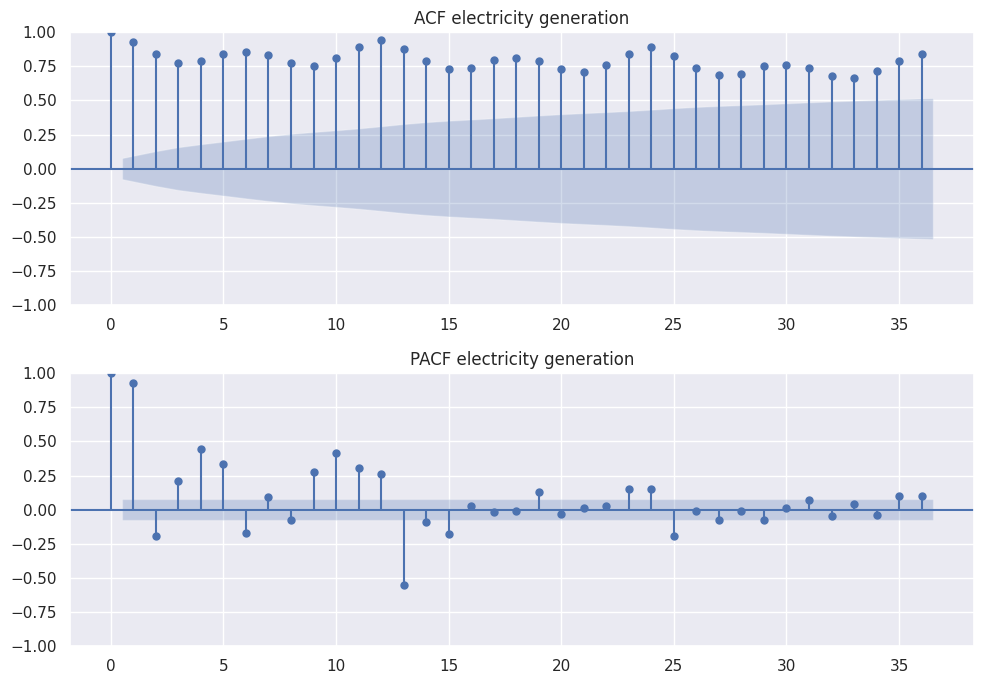

In [12]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

#ACF and PACF
fig, ax = plt.subplots(2, 1, figsize=(10,7))

sm.graphics.tsa.plot_acf(data['Value'], lags=36, ax=ax[0])
ax[0].set_title('ACF electricity generation')

sm.graphics.tsa.plot_pacf(data['Value'], lags=36, ax=ax[1])
ax[1].set_title('PACF electricity generation')

plt.tight_layout()
plt.show()

**YOUR ANSWER HERE**

The ACF values are quite big and slowly decrease up to 36 lags, reflecting both the trend and non-stationarity of the time series. Peaks can be seen at lags 12, 24, and 36, showing an annual seasonality. There is a large spike at lag 1 for the PACF and several other important spikes, including those at seasonal lags.
Given that the initial time series remains non-stationary, there are no stationary AR or MA structures revealed by ACF and PACF. Taking into account the trend, increasing variability and seasonality, the use of log transformation, first and seasonal differences at lag 12 should be reasonable.

## 3. Stationarity of the Time Series

Above you were asked to eyeball the data and form an opinion on the possibility for the time series to be stationary. We can use a statistical test to formalize this, such as the ADF and KPSS tests. In the cell below you are expected to test the stationarity of the time series using the ADF and KPSS tests. Note that the deterministic components alter the test hypothesis.

What do you conclude from the ADF and KPSS tests? Is the time series stationary? What are the implications for the modeling of the time series? Explain your reasoning for the chosen specification of the tests.

In [13]:
from statsmodels.tsa.stattools import adfuller, kpss

#ADF test
adf = adfuller(data['Value'], regression='ct', autolag='AIC')

print('ADF statistic:', adf[0])
print('p-value:', adf[1])
print('lags:', adf[2])
print('critical values:', adf[4])

print()

#KPSS test
kpss_test = kpss(data['Value'], regression='ct', nlags='auto')

print('KPSS statistic:', kpss_test[0])
print('p-value:', kpss_test[1])
print('lags:', kpss_test[2])
print('critical values:', kpss_test[3])

ADF statistic: -1.2496909494047435
p-value: 0.8998158711348163
lags: 14
critical values: {'1%': np.float64(-3.97328161237995), '5%': np.float64(-3.417515401755724), '10%': np.float64(-3.1311838387495707)}

KPSS statistic: 1.344929750977811
p-value: 0.01
lags: 9
critical values: {'10%': 0.119, '5%': 0.146, '2.5%': 0.176, '1%': 0.216}


/tmp/ipykernel_581/4105417700.py:4: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf = adfuller(data['Value'], regression='ct', autolag='AIC')
/tmp/ipykernel_581/4105417700.py:14: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  kpss_test = kpss(data['Value'], regression='ct', nlags='auto')
/tmp/ipykernel_581/4105417700.py:14: FutureWarning: kpss currently returns a plain tuple whose length and layout depends on the store argument (and which silently drops `lags` when store=True). In release 0.16 or after July 2027, whichever is later, the default behavior will

ADF test fails to reject the hypothesis of unit root (p-value = 0.898). However, KPSS test rejects the hypothesis of trend stationary (p-value smaller than 0.01). Therefore, from both the tests, it can be observed that the original series of electricity generation is non-stationary. In both the tests, a constant and deterministic trend have been included because the graph indicates an upward trend.

## 4. Transform the Time Series

Given the result from the stationarity tests and the visual inspection of the time series, we might need to transform the time series to make it stationary. In the cell below, you are expected to transform the time series to make it stationary. Once you have transformed the time series, visualize the transformed time series.

Do you believe the transformed time series is stationary?

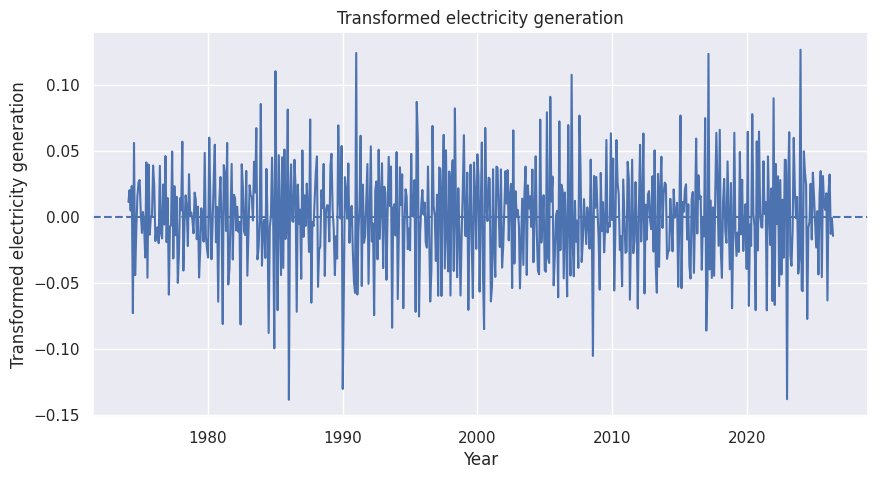

In [14]:
import numpy as np
import matplotlib.pyplot as plt

#log transformation
log_data = np.log(data['Value'])

#first difference and seasonal difference
transformed = log_data.diff().diff(12).dropna()

#plot
plt.figure(figsize=(10,5))
plt.plot(transformed)
plt.axhline(0, linestyle='--')
plt.xlabel('Year')
plt.ylabel('Transformed electricity generation')
plt.title('Transformed electricity generation')
plt.show()

I applied a logarithmic transformation to stabilize the variance, followed by first differencing to remove the trend and seasonal differencing with period 12 to remove the annual seasonal pattern. The result is that now the data fluctuates around zero, having constant variance and neither trend nor seasonality visible. Consequently, just by visually examining the series, we can state that it appears to be stationary, though there are still some large spikes left without any clear pattern.

## 5. Validate the Stationarity of the Transformed Time Series
In the cell below you are expected to validate the stationarity of the transformed time series using the ADF and KPSS tests. What do you conclude from the ADF and KPSS tests? Is the transformed time series stationary? Explain your reasoning for the chosen specification of the tests.

In [15]:
from statsmodels.tsa.stattools import adfuller, kpss

#ADF test
adf = adfuller(transformed, regression='c', autolag='AIC')

print('ADF statistic:', adf[0])
print('p-value:', adf[1])
print('lags:', adf[2])
print('critical values:', adf[4])

print()

#KPSS test
kpss_result = kpss(transformed, regression='c', nlags='auto')

print('KPSS statistic:', kpss_result[0])
print('p-value:', kpss_result[1])
print('lags:', kpss_result[2])
print('critical values:', kpss_result[3])

ADF statistic: -9.518458497646828
p-value: 3.1109980666086967e-16
lags: 18
critical values: {'1%': np.float64(-3.441115625417986), '5%': np.float64(-2.866289751785392), '10%': np.float64(-2.56929951625907)}

KPSS statistic: 0.05020052213314163
p-value: 0.1
lags: 46
critical values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}


/tmp/ipykernel_581/4238564062.py:4: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf = adfuller(transformed, regression='c', autolag='AIC')
/tmp/ipykernel_581/4238564062.py:14: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kpss_result = kpss(transformed, regression='c', nlags='auto')
/tmp/ipykernel_581/4238564062.py:14: FutureWarning: kpss currently returns a plain tuple whose length and layout depends on the store argument (and which silently drops `lags` when store=True). In release 0.16 or after July 2027, whichever is later, the default behavior will swi

the ADF test strongly rejects the presence of a unit root (p-value close to 0), whereas the KPSS test fails to reject the presence of stationarity (p-value equal or greater than 0.10). Thus, it can be concluded that both tests prove the stationary nature of the transformed series. A model with a constant but without a deterministic trend was used because the transformed series moves at a certain level and does not have any trend at all.

# PART 2: Baseline Model (15 pts)

## 6. Model Structure

You are asked to plot the autocorrelation function (ACF) and partial autocorrelation function (PACF) of the transformed time series in the cell below. You can set the amount of lags equal 36 (equivalent to 3 years).

What do you observe in the ACF and PACF plots? What kind of dynamics are present in the time series? What kind of model structure would you propose for the time series? Explain your reasoning.

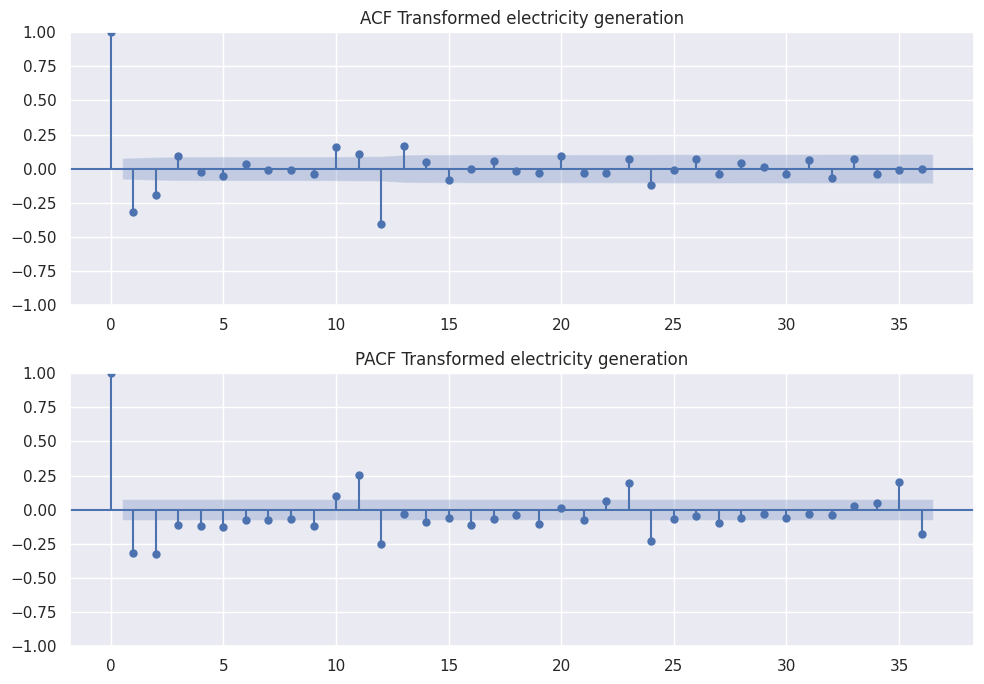

In [ ]:
# ACF and PACF
fig, ax = plt.subplots(2, 1, figsize=(10,7))

tsa.graphics.plot_acf(transformed, lags=36, ax=ax[0])
ax[0].set_title('ACF Transformed electricity generation')


tsa.graphics.plot_pacf(transformed, lags=36, ax=ax[1])
ax[1].set_title('PACF Transformed electricity generation')

plt.tight_layout()
plt.show()

In the ACF there is no slow decay visible, whereas there was before the transformation. This means that the transformation is successful and that the series appears stationary. The ADF and KPSS tests in part 1 confirm that the transformed series is indeed stationary. The ACF has significant lags at 1, 2 and 12 of approximately -0.32, -0.19, -0.42. The PACF has significant lags at 1, 2 and negative spikes at lags 12, 24 and 36 of approximately -0.25, -0.23, -0.18. So, with diminishing magnitude.

There are seasonal and non-seasonal dynamics present in the plots. The seasonal dynamics are visible in the single ACF spike at lag 12 combined with the gradual PACF decay at lags 12, 24 and 36. This combination identifies a seasonal MA(1) instead of a seasonal AR(1). So P=0, Q=1 and s=12. The non-seasonal dynamics are visible in the ACF when it cuts off after lag 2 combined with the PACF that decays slowly. This points to a MA(2) model with p=0 and q=2. However the signal is weak and not very clear-cut, so an AR specification cannot be ruled out.

In part 1 the series was transformed by taking logs to stabilise the variance, by taking the first difference to remove the trend and lastly by taking a seasonal difference at lag 12 to remove the annual pattern. This implies d=1 and D=1 in the SARIMA model.

So the proposed model is the SARIMA(0,1,2)x(0,1,1)12 model on the log series. Given the lack of a clear cut-off in the non-seasonal component mentioned above, a broader set of specifications is evaluated in part 3 using information criteria.

## 7. Model Estimation

In the cell below you are expected to estimate the model structure you proposed in the previous question. You can use the `ARIMA` and/or `SARIMAX` method from the `statsmodels` library to estimate the model.

Once you have estimated your model, print the summary of the model. How do you interpret the model coefficients? Are they statistically significant? Comment on the fit of the model based on residual diagnostics.

In [16]:
# YOUR CODE HERE
raise NotImplementedError

NotImplementedError: 

**YOUR ANSWER HERE**

# PART 3: Model Selection In-Sample (15 pts)

## 8. Model Selection Based on Information Criteria

In the cell below you are expected to select the best model based on the BIC. Based on your initial guess of the model structure, choose a set of models to estimate.

For your chosen model, report the BIC value and comment on the model fit (using residual diagnostics and appropriate tests). Furthermore, compare your optimal model with the model you estimated in the previous question.

In [ ]:
# YOUR CODE HERE
raise NotImplementedError

**YOUR ANSWER HERE**

# PART 4: Model Selection Out-of-Sample (20 pts)

## 9. Model Selection Based on Cross-Validation

In the cells below you are expected to select the best models based on time series cross-validation for 1-, 6-, and 12-step ahead forecasts based on the same set of models evaluated above. The initial training set consists of all observations except for the last 10 years (120 observations) of data. You can evaluate the models based on the mean squared error (MSE).

For each of your chosen models report the MSE value. Are your optimal models based on 1-, 6-, and 12-step ahead forecasts different? Compare your optimal models with the optimal model you selected based on the BIC. Do they differ, and, if so, how?

In [ ]:
# YOUR CODE HERE
raise NotImplementedError

**YOUR ANSWER HERE**

### 1-Step Ahead

In [ ]:
# YOUR CODE HERE
raise NotImplementedError

**YOUR ANSWER HERE**

### 6-Step Ahead

In [ ]:
# YOUR CODE HERE
raise NotImplementedError

**YOUR ANSWER HERE**

### 12-Step Ahead

In [ ]:
# YOUR CODE HERE
raise NotImplementedError

**YOUR ANSWER HERE**

# PART 5: Benchmarking (25 pts)

## 10. Model Comparison Against a Naive Benchmark

In the cell below you are expected to compare the forecasts of your optimal models based on time series cross-validation against forecasts of a naive benchmark using the same time series cross-validation setup as explained above. Note that this implies that you can use the results (forecasts) from the cross-validation exercise above. In other words, there is no need you do to redo the forecasts for the test sets using your optimal models.

The naïve benchmark forecasts the US total energy generation using the seasonal naïve method with drift

$$\hat{X}_{t}(h) = X_{t+h-s(k+1)} + h \frac{X_{t} - X_{1}}{t - 1}$$

where $X_{t}$ is the US total energy generation at time $t$, $s$ is the seasonal period, and $k$ is the integer part of $(h - 1)/s$ (i.e. the number of complete years in the forecast period prior to time $t + h$). This sounds complicated, but it merely means that for example, with monthly data, the forecast for all future February values is equal to the last observed February value. The second component of the forecast is the drift, which is the average change seen in the time series up to time $t$ and extrapolated to time $t + h$.

Plot the $h$-step ahead forecasts from your $h$-step ahead cross-validated model together with the corresponding naive benchmark $h$-step ahead forecasts and the actual US total energy generation. Comment on the forecast performance of your optimal models compared to the naive benchmark. Perform a Diebold-Mariano test to test whether the differences in the forecasting performance for the different horizons are statistically significant. Which model would you recommend for forecasting the US total energy generation?

In [ ]:
# YOUR CODE HERE
raise NotImplementedError

**YOUR ANSWER HERE**